In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle
import seaborn as sns
from funcs import Neutrinos_dk2nu

DET_I = 5 #SBND Index
DET_A = 4*np.pi*1e4 # Detector area

data = Neutrinos_dk2nu("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root")


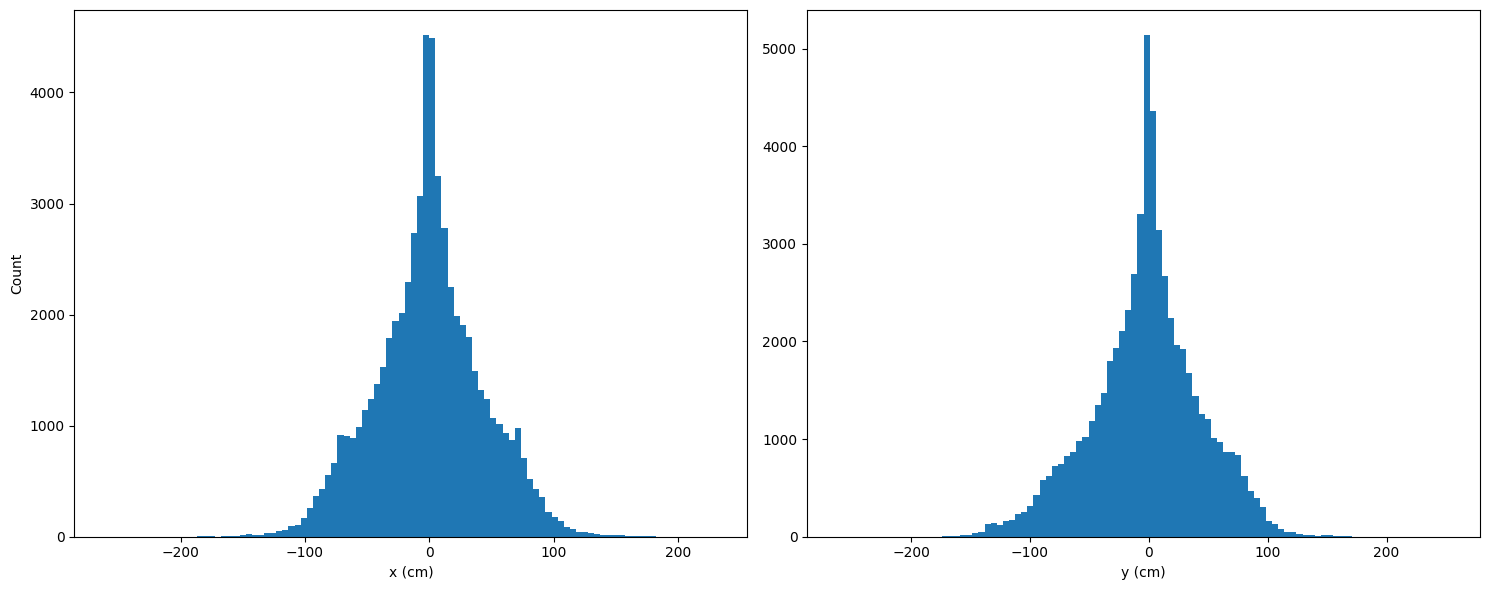

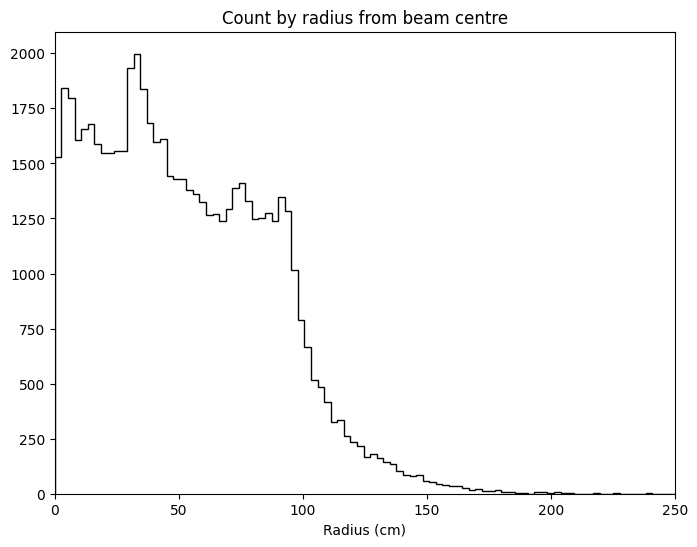

In [2]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax1.hist(data.decay_x, bins=100)
ax2.hist(data.decay_y, bins=100)

ax1.set_xlabel("x (cm)")
ax1.set_ylabel("Count")
ax2.set_xlabel("y (cm)")

fig.tight_layout()

radii = np.sqrt(data.decay_x**2 + data.decay_y**2)
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(radii, bins=100,histtype="step", color="black")

ax.set_xlim(0,250)
ax.set_xlabel("Radius (cm)")
ax.set_title("Count by radius from beam centre")
plt.show()

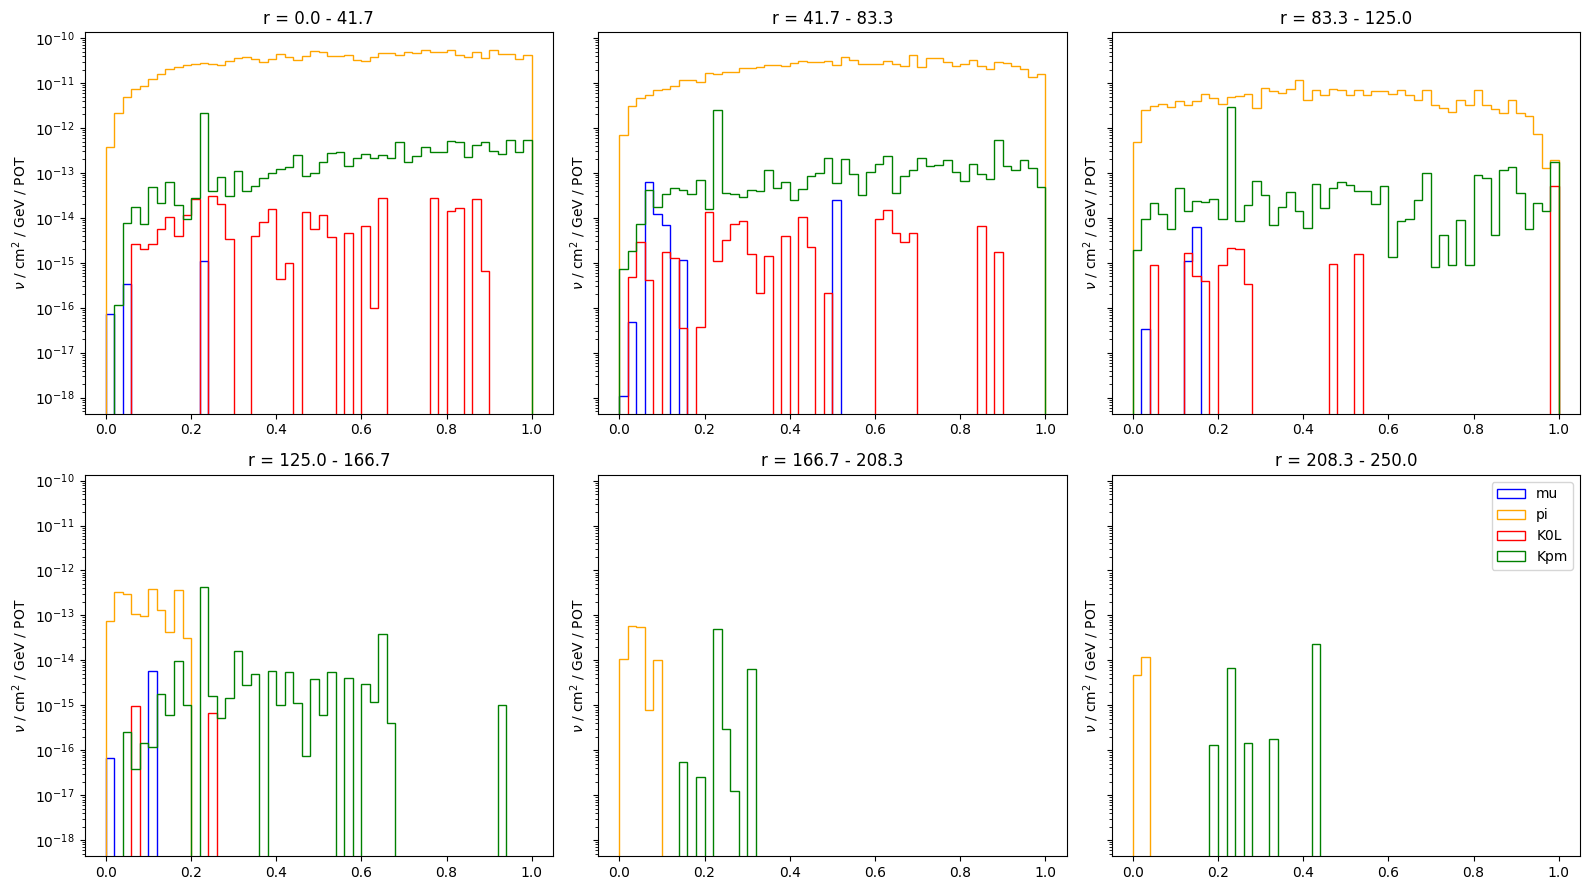

KDAR energy window: 235-236 MeV (0.235-0.236 GeV)
0.0-41.7 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.483, Events=43.43640339570183
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.517, Events=46.40737872350584

41.7-83.3 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.171, Events=10.98756200385883
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.829, Events=53.231095188907936

83.3-125.0 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.099, Events=6.787361519508942
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.901, Events=62.05632181239678

125.0-166.7 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=1.000, Events=8.91984763369061

166.7-208.3 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=1.000, Events=1.0409971868713725

208.3-250.0 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : rati

In [3]:


rows, columns = 2, 3
fig, axs = plt.subplots(rows,columns, figsize=(16, 9), sharey=True)
bins = np.linspace(0, 1, 51)  # GeV

nbins = rows * columns
edges = np.linspace(0,250,nbins+1)

radial_masks = []
for i in range(len(edges)-1):
    radial_masks.append((radii >= edges[i]) & (radii < edges[i+1]))



for r in range(rows):
    for c in range(columns):
        
        mask = data.flavour_mask(14) & radial_masks[r*columns + c] & data.energy_mask()

        for label, (parent_pdgs, colour) in data.parent_groups.items():
                full_mask = mask & data.parent_mask(parent_pdgs)
                axs[r][c].hist(data.energies[full_mask], bins=bins, weights=data.tot_wgts[full_mask],
                        label=label, color=colour, histtype="step", linewidth=1)

        axs[r][c].set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
        axs[r][c].set_yscale("log")
        axs[r][c].set_title(f"r = {(r*columns + c)*(250/nbins):.1f} - {(r*columns + c+1)*(250/nbins):.1f}")

axs[rows-1][columns-1].legend()
fig.tight_layout()
plt.show()


kdar_mask = data.energy_mask([0.235,0.236])
print("KDAR energy window: 235-236 MeV (0.235-0.236 GeV)")

for i in range(len(edges)-1):
    edge_lo = edges[i]
    edge_hi = edges[i+1]
    rmask = radial_masks[i]
    mask =  rmask & kdar_mask & data.flavour_mask(14)

    total_weighted = np.sum(data.tot_wgts[mask])
    total_counts = np.count_nonzero(mask)

    print(f"{edge_lo:.1f}-{edge_hi:.1f} cm")
    if total_weighted <= 0:
        print("  (no events in this bin)")
        continue

    for label, (p_pdgs, colour) in data.parent_groups.items():
        w = np.sum(data.tot_wgts[mask & data.parent_mask(p_pdgs)])
        n = np.count_nonzero(mask & data.parent_mask(p_pdgs))
        event_count = data.event_count([0.235,0.236], 14, p_pdgs, rmask)
        ratio = w / total_weighted
        print(f"  {label:4s}: ratio={ratio:.3f}, Events={event_count}")

    print()